# Course Project N.03: Clinical Records
**authors:** Vojtěch Tichý, Sávio Campos de Souza <br>

overleaf link: https://www.overleaf.com/3315726454qptfqhmwhcpy#04e0ee

explanation of attributes: https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008
explanation of ICD9 codes (`diag1/2/3` columns): https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Publications/ICD-9/ucod.txt

In [147]:
%pip install -q numpy pandas matplotlib seaborn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Note: you may need to restart the kernel to use updated packages.


In [148]:
df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/diabetic_data.csv')
ids_df = pd.read_csv('03_ClinicalRecords_Clustering/20_Clinical Records/IDs_mapping.csv')

df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [149]:
ids_df

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
...,...,...
62,22,Transfer from hospital inpt/same fac reslt in...
63,23,Born inside this hospital
64,24,Born outside this hospital
65,25,Transfer from Ambulatory Surgery Center


First, we process the dataframes with mappings and combine them with dataset.

In [150]:
admission_type_id_mapping = ids_df.loc[0:8]
discharge_disposition_id_mapping = ids_df.loc[10:40]
admission_source_id_mapping = ids_df.loc[42:]

admission_type_id_mapping = dict(zip(admission_type_id_mapping['admission_type_id'].values, 
                                     admission_type_id_mapping['description'].values))
discharge_disposition_id_mapping = dict(zip(discharge_disposition_id_mapping['admission_type_id'].values, 
                                            discharge_disposition_id_mapping['description'].values))
admission_source_id_mapping = dict(zip(admission_source_id_mapping['admission_type_id'].values,
                                       admission_source_id_mapping['description'].values))

# because the dictionaries have indexes as str, so that it can be mapped
df['admission_source_id'] = df['admission_source_id'].astype(str)
df['admission_type_id'] = df['admission_type_id'].astype(str)
df['discharge_disposition_id'] = df['discharge_disposition_id'].astype(str)

df['admission_type_id'] = df['admission_type_id'].map(admission_type_id_mapping)
df['discharge_disposition_id'] = df['discharge_disposition_id'].map(discharge_disposition_id_mapping)
df['admission_source_id'] = df['admission_source_id'].map(admission_source_id_mapping)

df['admission_source_id'] = df['admission_source_id'].astype('category')
df['admission_type_id'] = df['admission_type_id'].astype('category')
df['discharge_disposition_id'] = df['discharge_disposition_id'].astype('category')

In [151]:
df.describe()

,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


## Exploratory analysis
First we look at the categorical attributes.

In [152]:

def plot_numerical_cols(df: pd.DataFrame, col_cnt: int = 4) -> None:
	"""
	@brief plots distributions of all numerical attributes

	@param df input dataframe
	@param col_cnt number of plot columns
	"""
	
	numerical_cols = df.select_dtypes(include=['int', 'float']).columns
	fig, axes = plt.subplots(len(numerical_cols) // 4 + 1, col_cnt, figsize=(12,20))
	axes = axes.flatten()

	for i, col in enumerate(numerical_cols):
		sns.violinplot(data=df, y=col, ax=axes[i])
		axes[i].set_ylabel("")
		axes[i].set_xlabel(col, fontsize=16)
	
	# to hide excess subplot axes 
	for i in range(len(numerical_cols), len(axes)):
		axes[i].set_visible(False)

	plt.suptitle('Violin plots of numerical attributes', fontsize=24, y=1)
	plt.tight_layout()
	plt.show()


def plot_categorical_cols(df: pd.DataFrame, col_cnt: int = 4) -> None:
	"""
	@brief plots a grid of countplots of all categorical attributes

	@param df input dataframe
	@param col_cnt number of plot columns
	"""
	
	categorical_cols = df.select_dtypes(include=['str', 'category', 'object']).columns
	fig, axes = plt.subplots(len(categorical_cols) // 4 + 2, col_cnt, figsize=(16,20))
	axes = axes.flatten()

	for i, col in enumerate(categorical_cols):
		sns.countplot(data=df, x=col, ax=axes[i])
		axes[i].set_ylabel("")
		axes[i].set_xlabel(col, fontsize=16)

		# hide ticks for plots with a lot of values, so that the plot grid is less cluttered and deformed
		# these will be processed with more caution later
		if df[col].nunique() > 15:
			axes[i].set_xticklabels([])
	
	# to hide excess subplot axes 
	for i in range(len(categorical_cols), len(axes)):
		axes[i].set_visible(False)

	fig.supylabel('Count', fontsize=20)
	plt.suptitle('Coutplots of categorical attributes', fontsize=24, y=1)
	plt.tight_layout()
	plt.show()


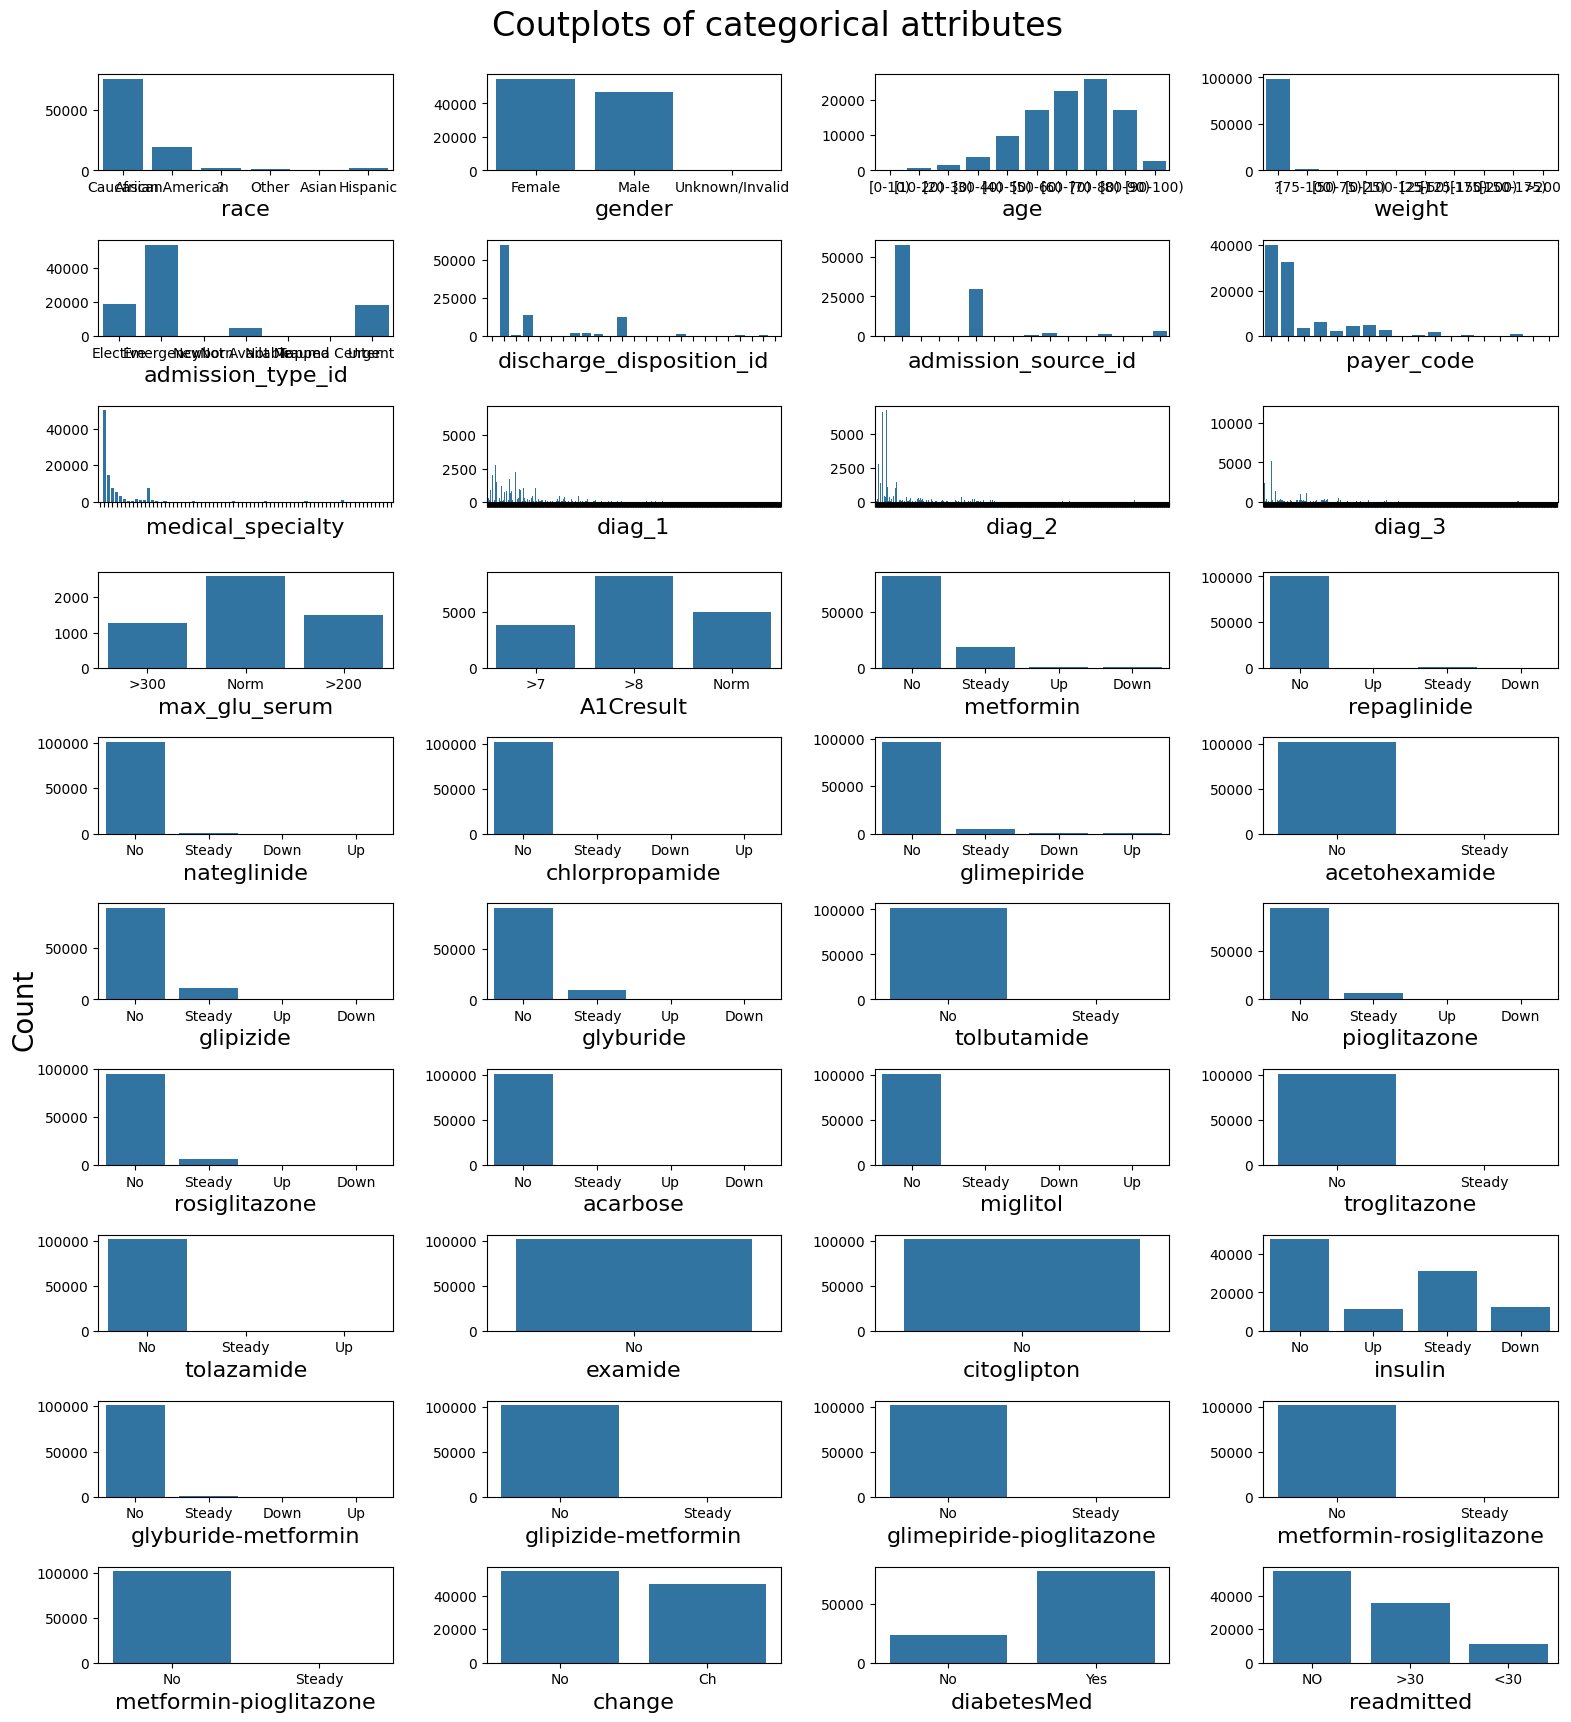

In [153]:
plot_categorical_cols(df)

From the graphs we can clearly see attributes, which have one values in all rows. We can drop thsese columns, since they do not bring any value. There are also a lot of columns which have one value in over 90% of its rows.

In [154]:
columns_to_drop = []

for col in df.columns:
    if len(df[col].unique()) <= 1 or np.max(df[col].value_counts()) / np.sum(df[col].value_counts()) >= 0.9:
        columns_to_drop.append(col) 

df.drop(columns=columns_to_drop, inplace=True)
print(f"{len(columns_to_drop)} columns are dropped: {columns_to_drop}")

20 columns are dropped: ['weight', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


### Numerical columns

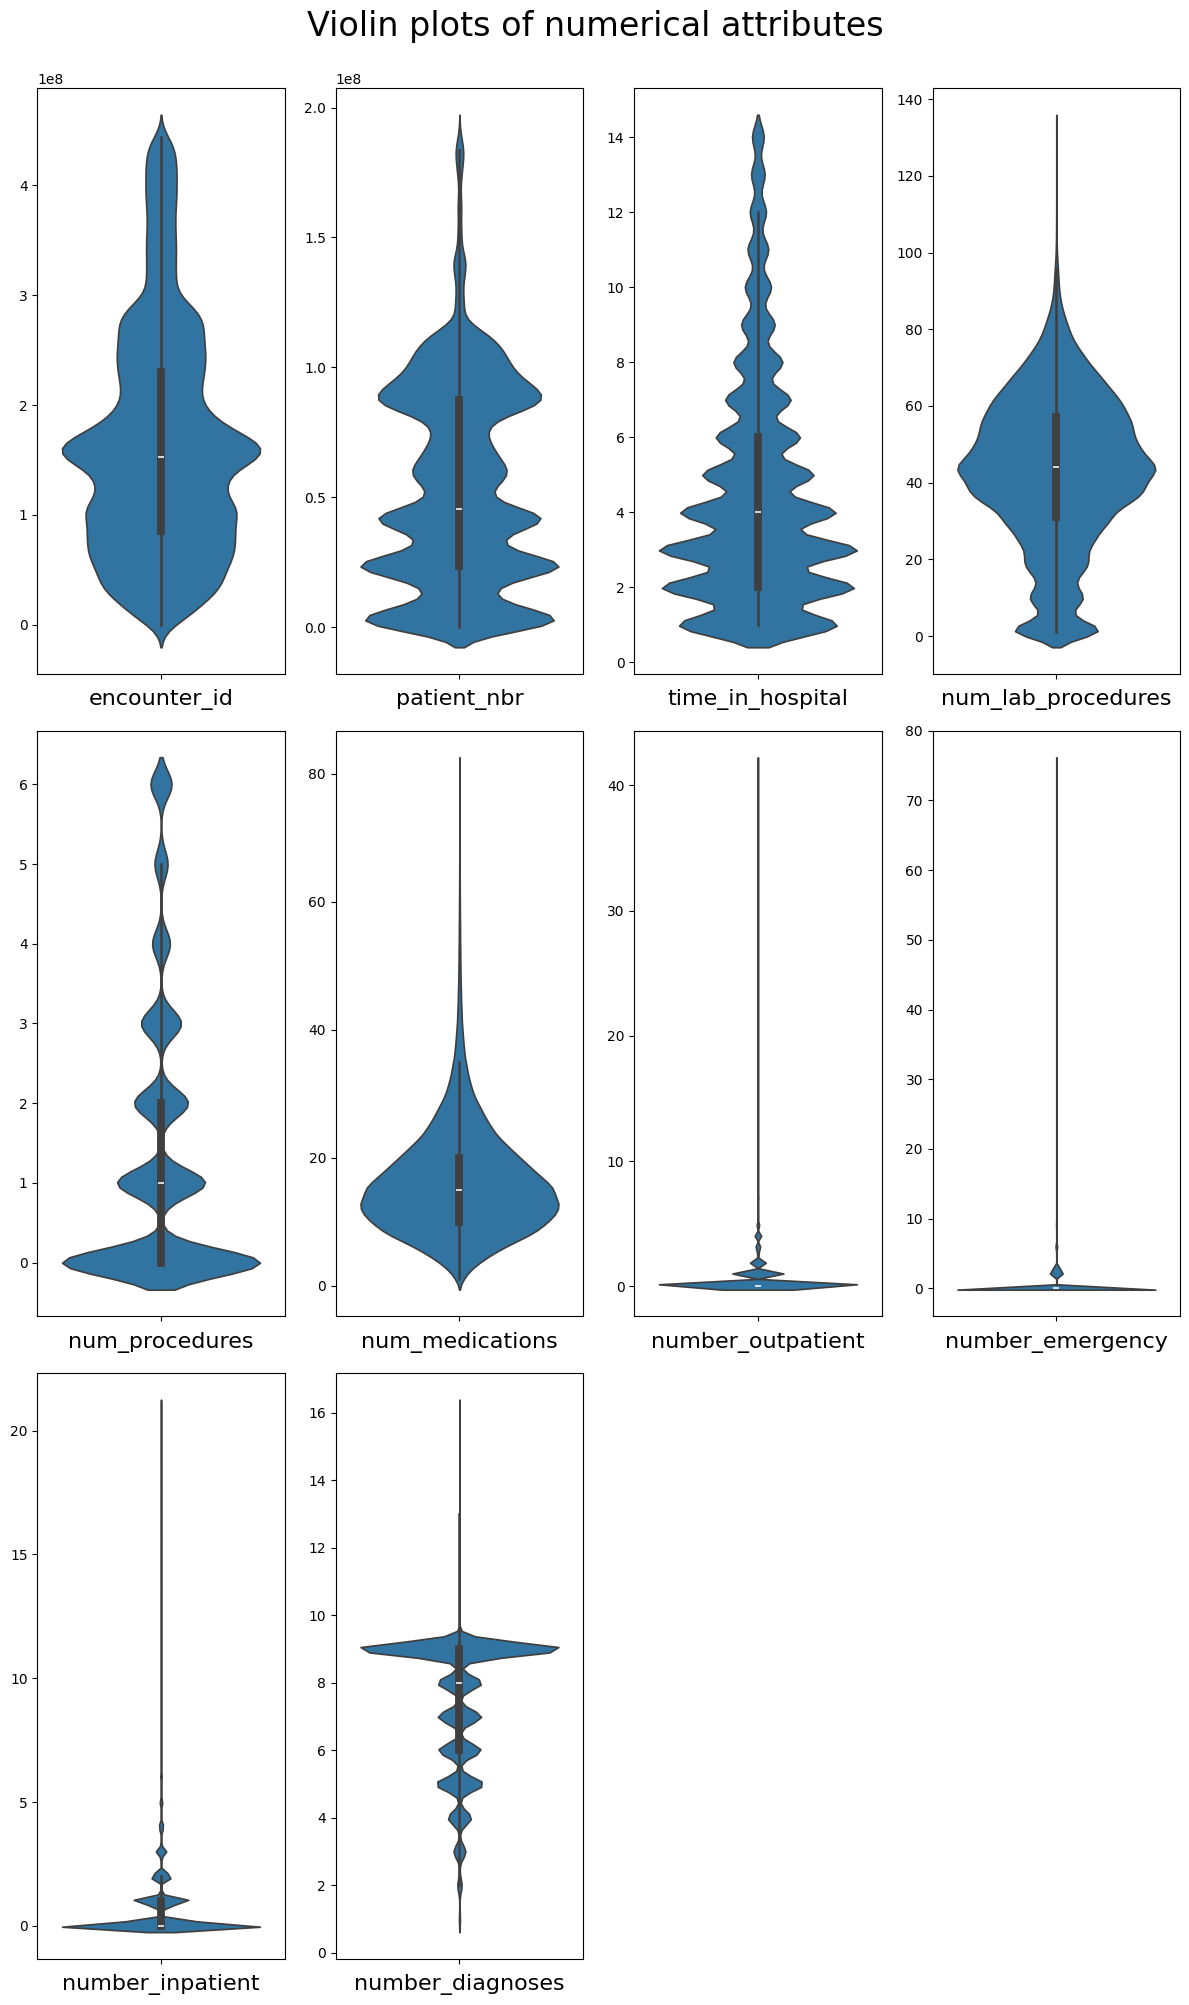

In [155]:
plot_numerical_cols(df)

<Figure size 1000x1000 with 0 Axes>

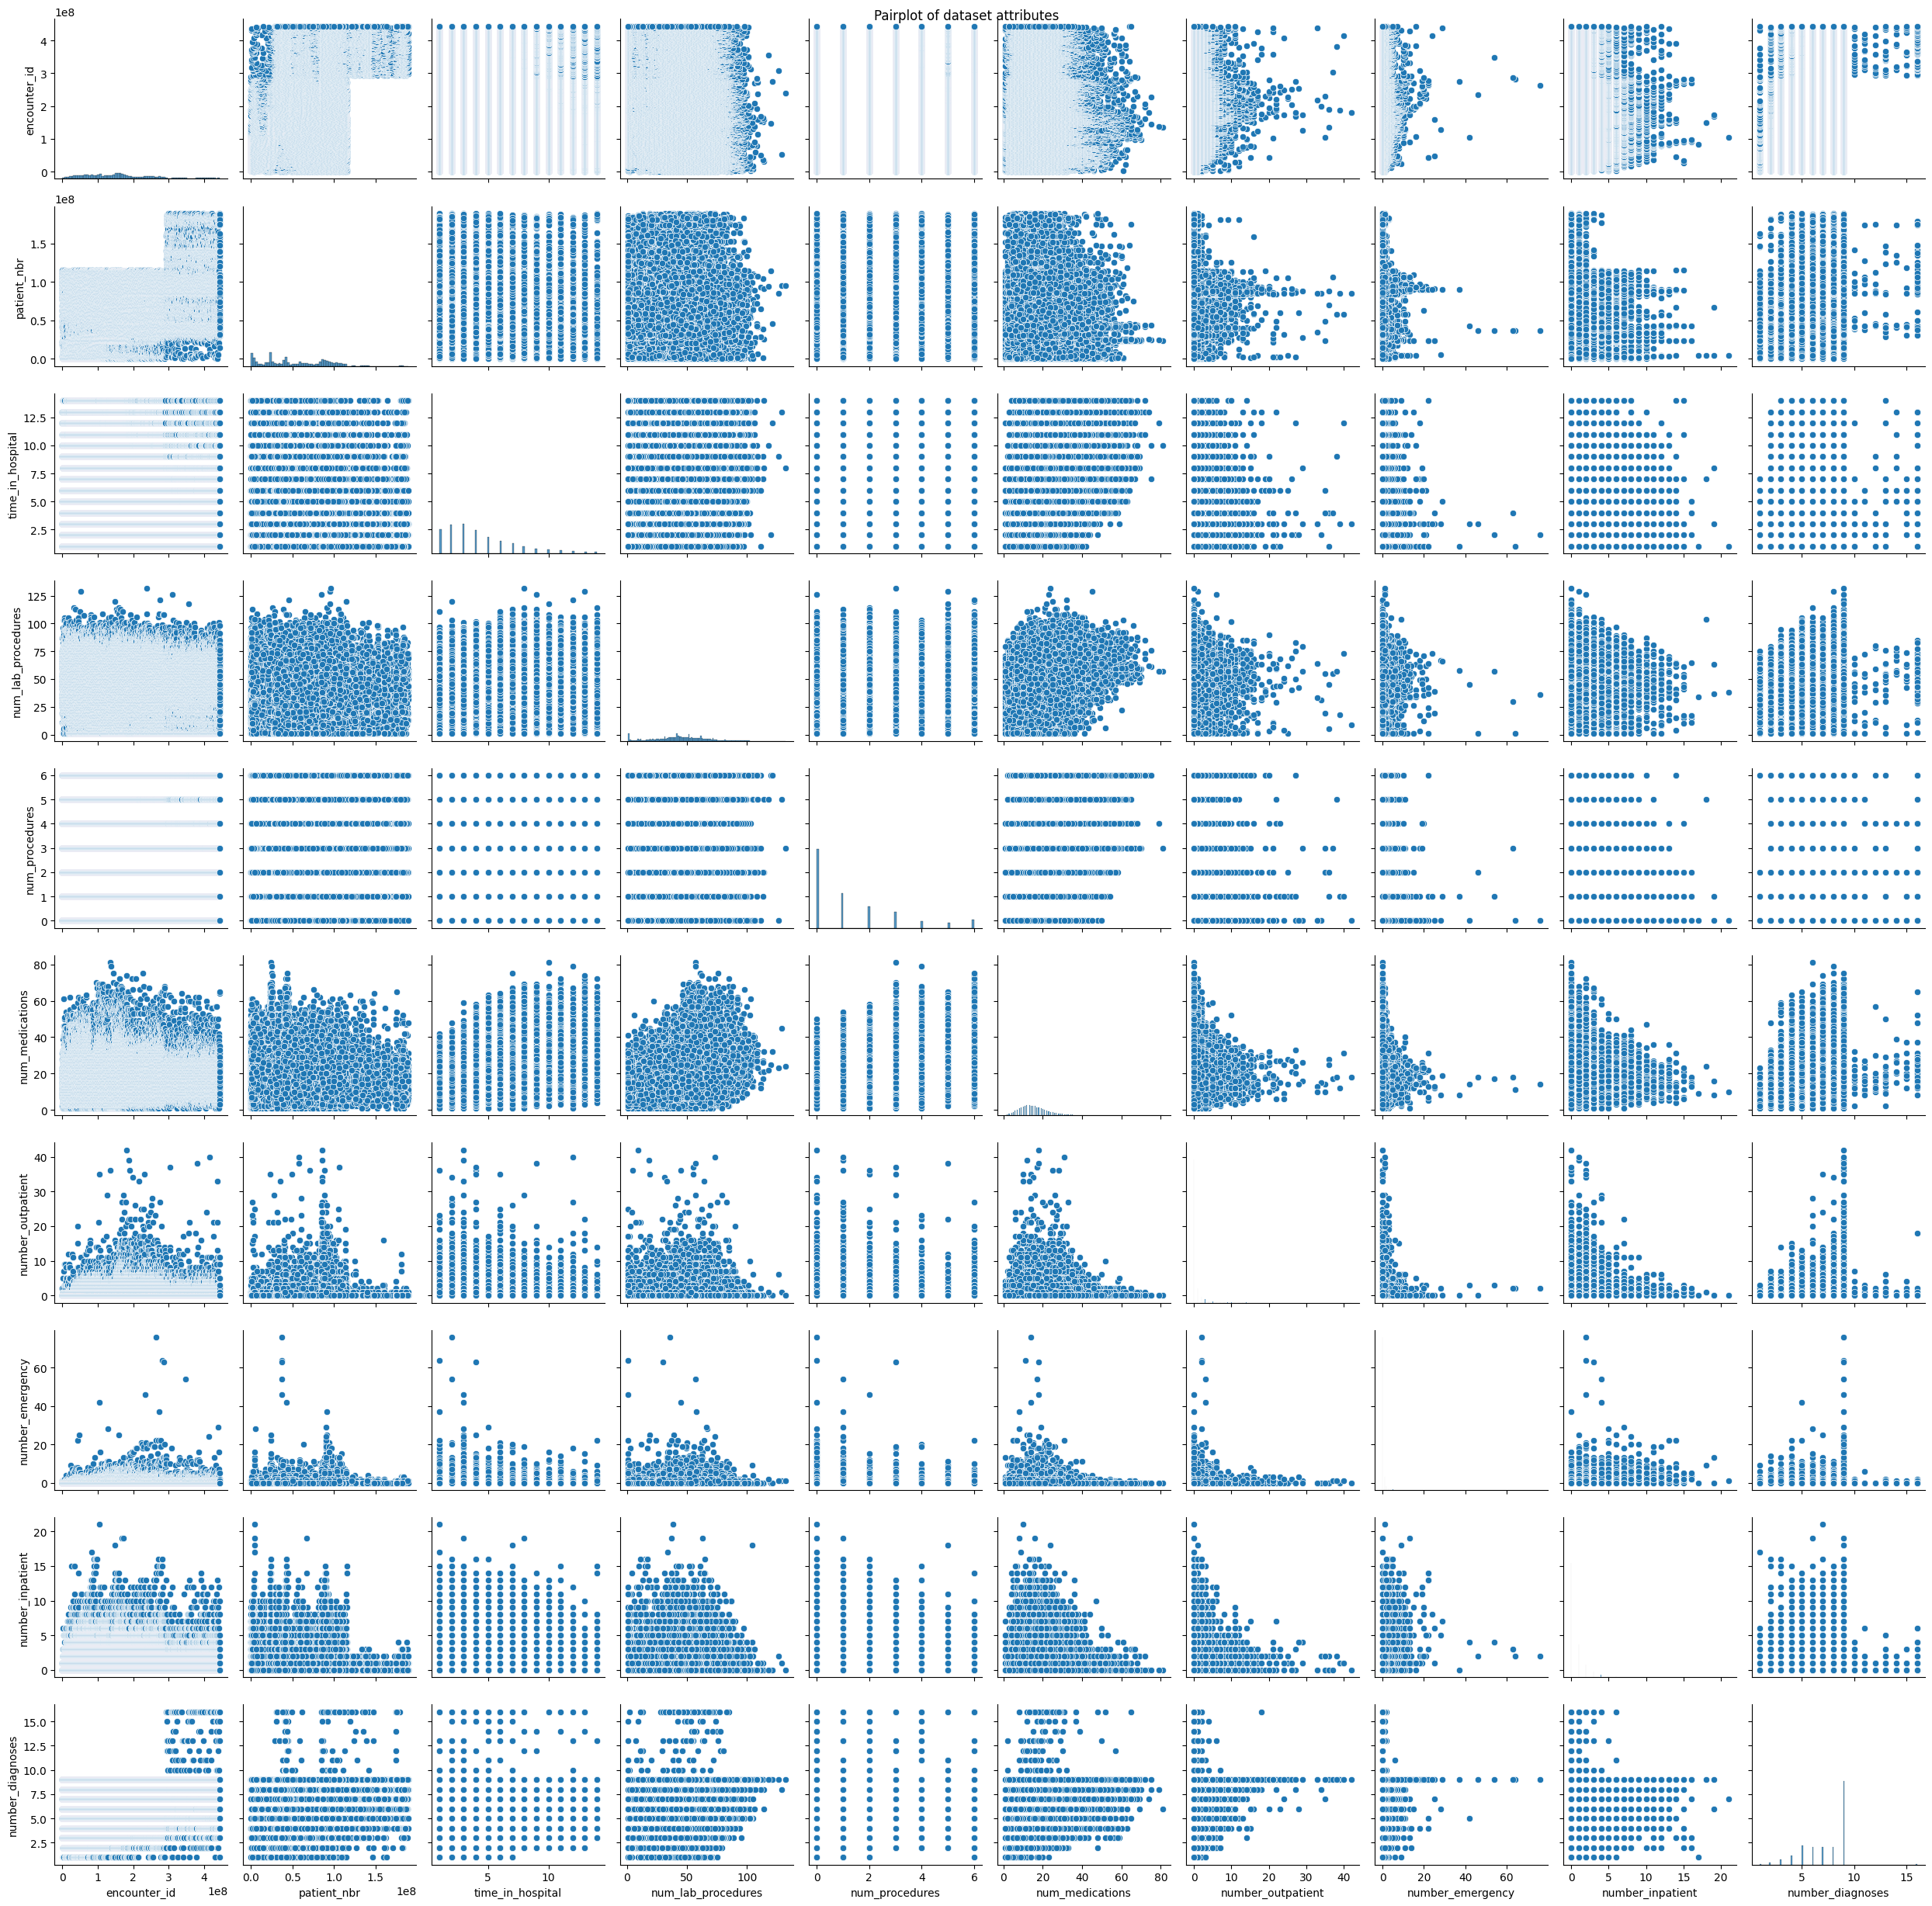

In [156]:
plt.figure(figsize=(10,10))
sns.pairplot(data=df)
plt.suptitle("Pairplot of dataset attributes")
plt.tight_layout()
plt.show()

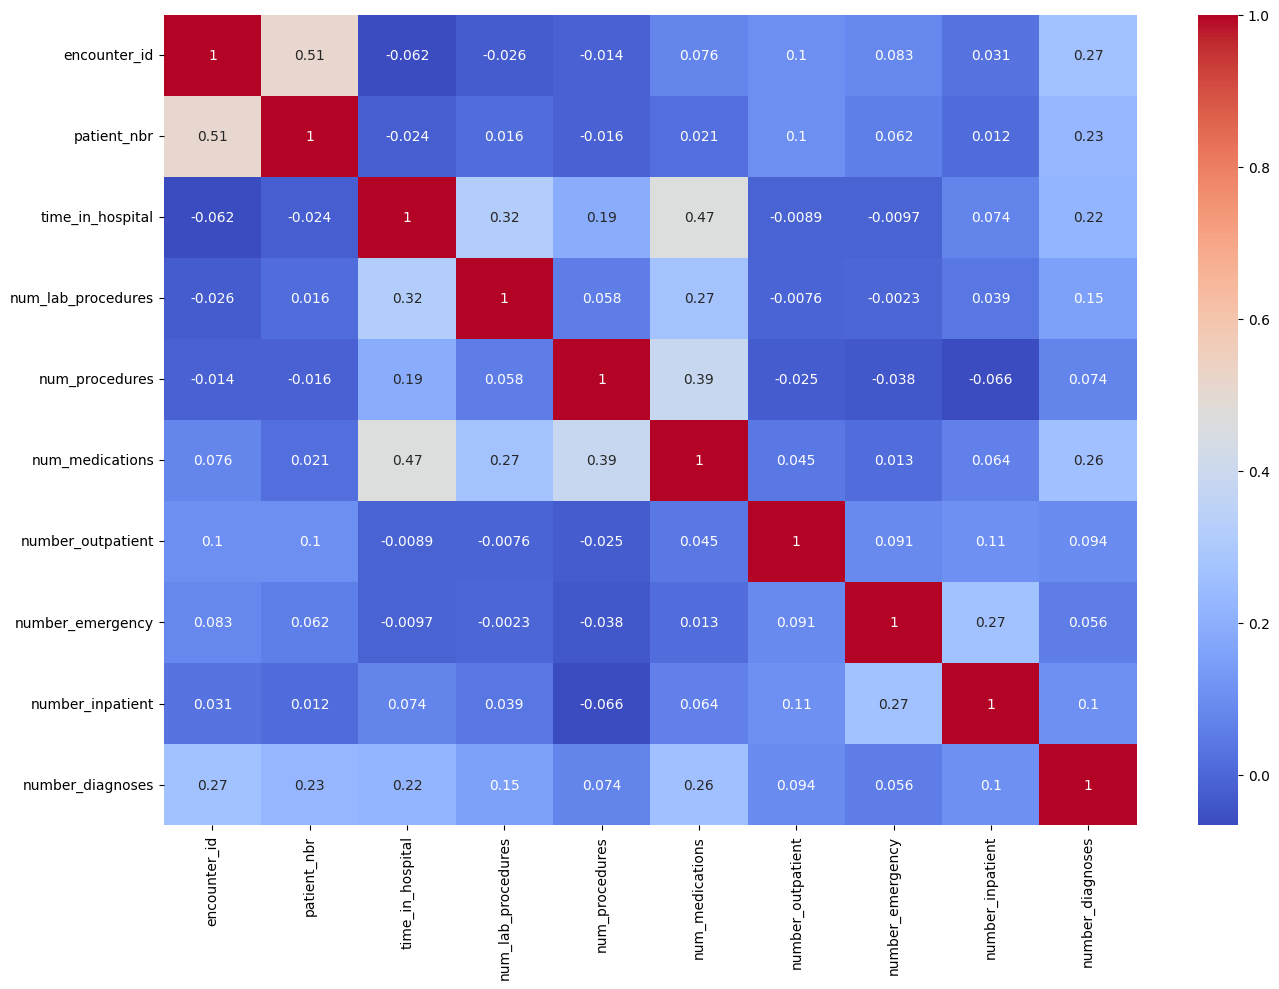

In [157]:
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(), annot=True, cmap='coolwarm')
plt.tight_layout()
plt.show()

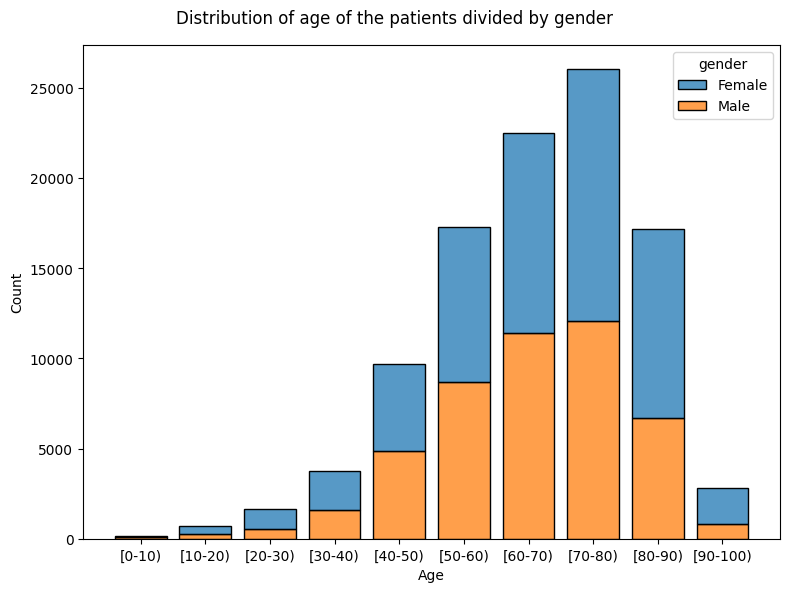

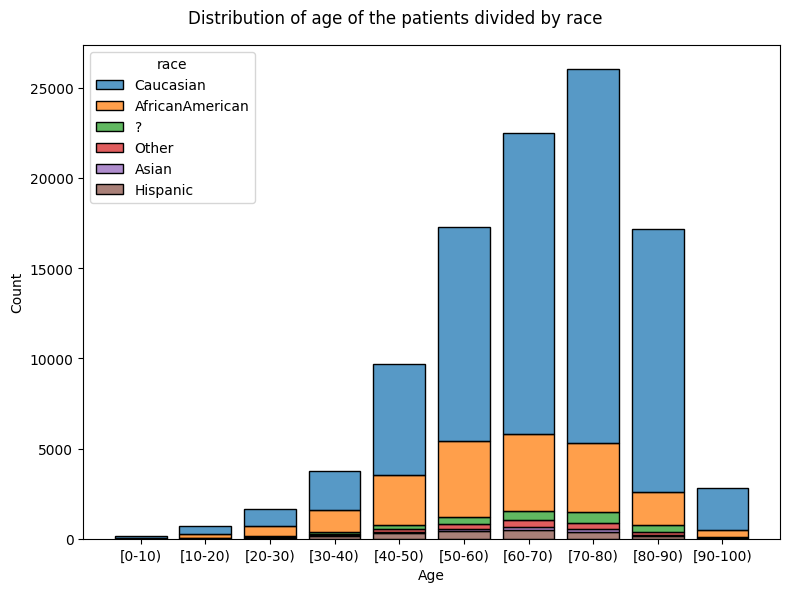

In [169]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='gender', multiple='stack', discrete=True, shrink=0.8)
plt.suptitle("Distribution of age of the patients divided by gender")
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='race', multiple='stack', discrete=True, shrink=0.8)
plt.suptitle("Distribution of age of the patients divided by race")
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Data preprocessing
After analyzing the dataset we can proceed with data preprocessing. In this section we will primarily:

1. drop columns with little to no information gain
2. fill values
3. transform columns

First we analyze columns containing `id`:

In [159]:
df['encounter_id'].value_counts(), df['patient_nbr'].value_counts()

(encounter_id
 2278392      1
 149190       1
 64410        1
 500364       1
 16680        1
             ..
 443847548    1
 443847782    1
 443854148    1
 443857166    1
 443867222    1
 Name: count, Length: 101766, dtype: int64,
 patient_nbr
 88785891     40
 43140906     28
 1660293      23
 23199021     23
 88227540     23
              ..
 183087545     1
 188574944     1
 140199494     1
 120975314     1
 175429310     1
 Name: count, Length: 71518, dtype: int64)

In [160]:
df.drop(columns=['patient_nbr', 'encounter_id'], inplace=True)

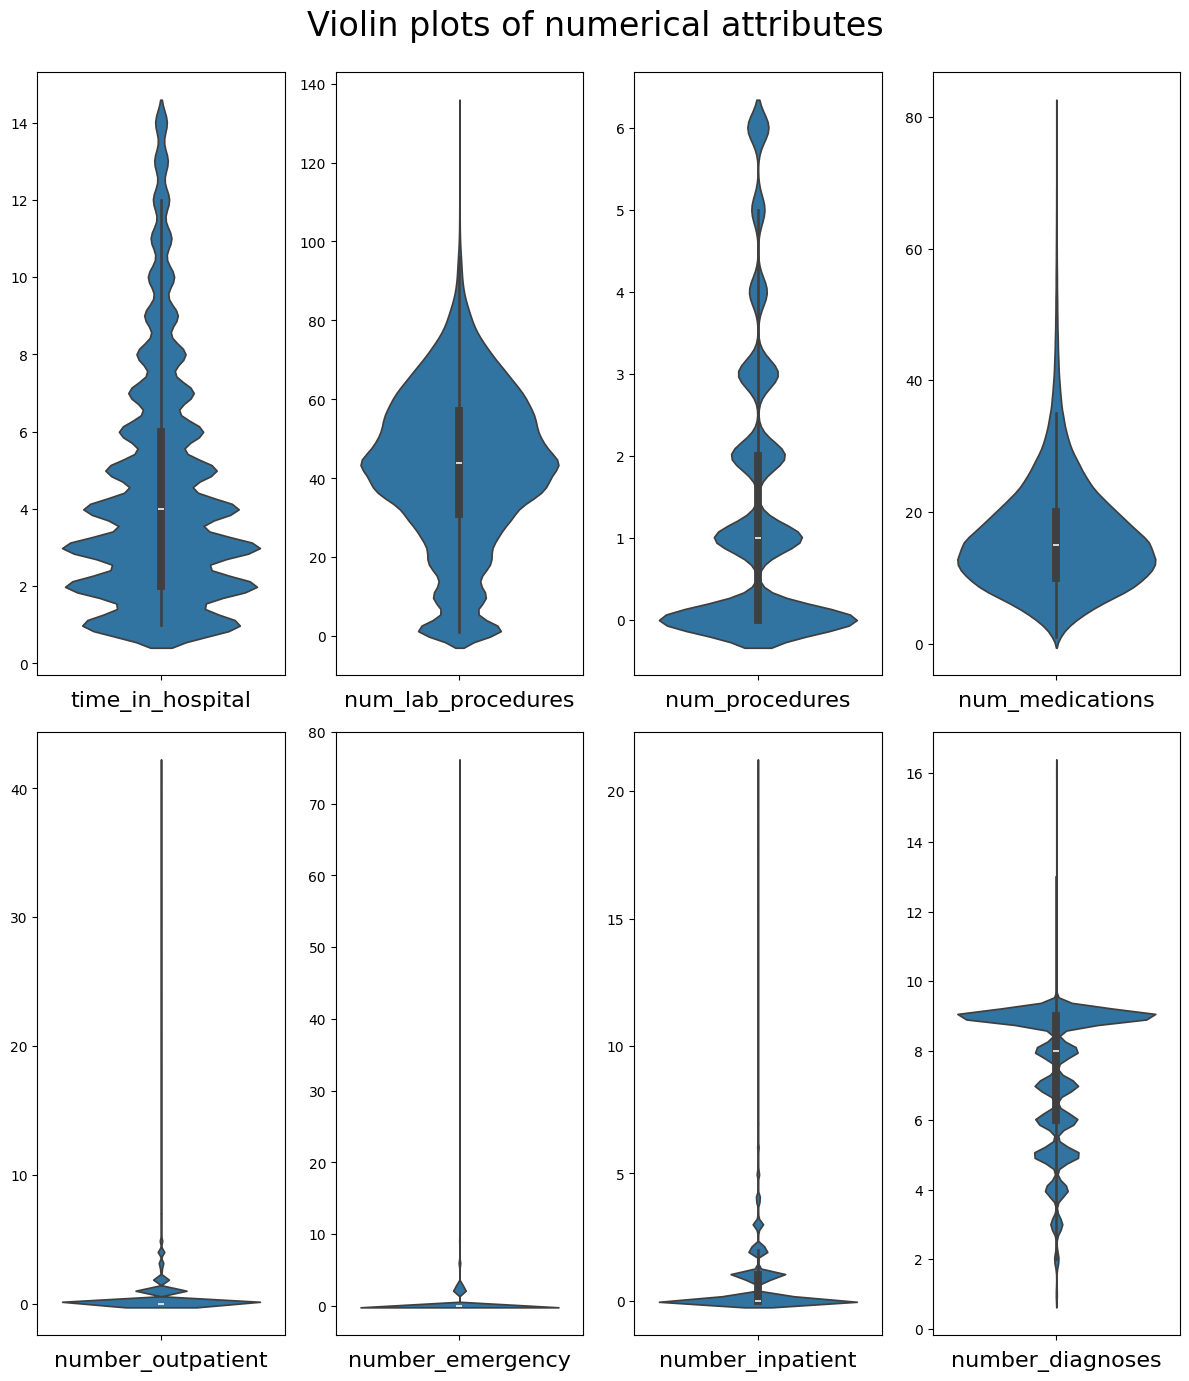

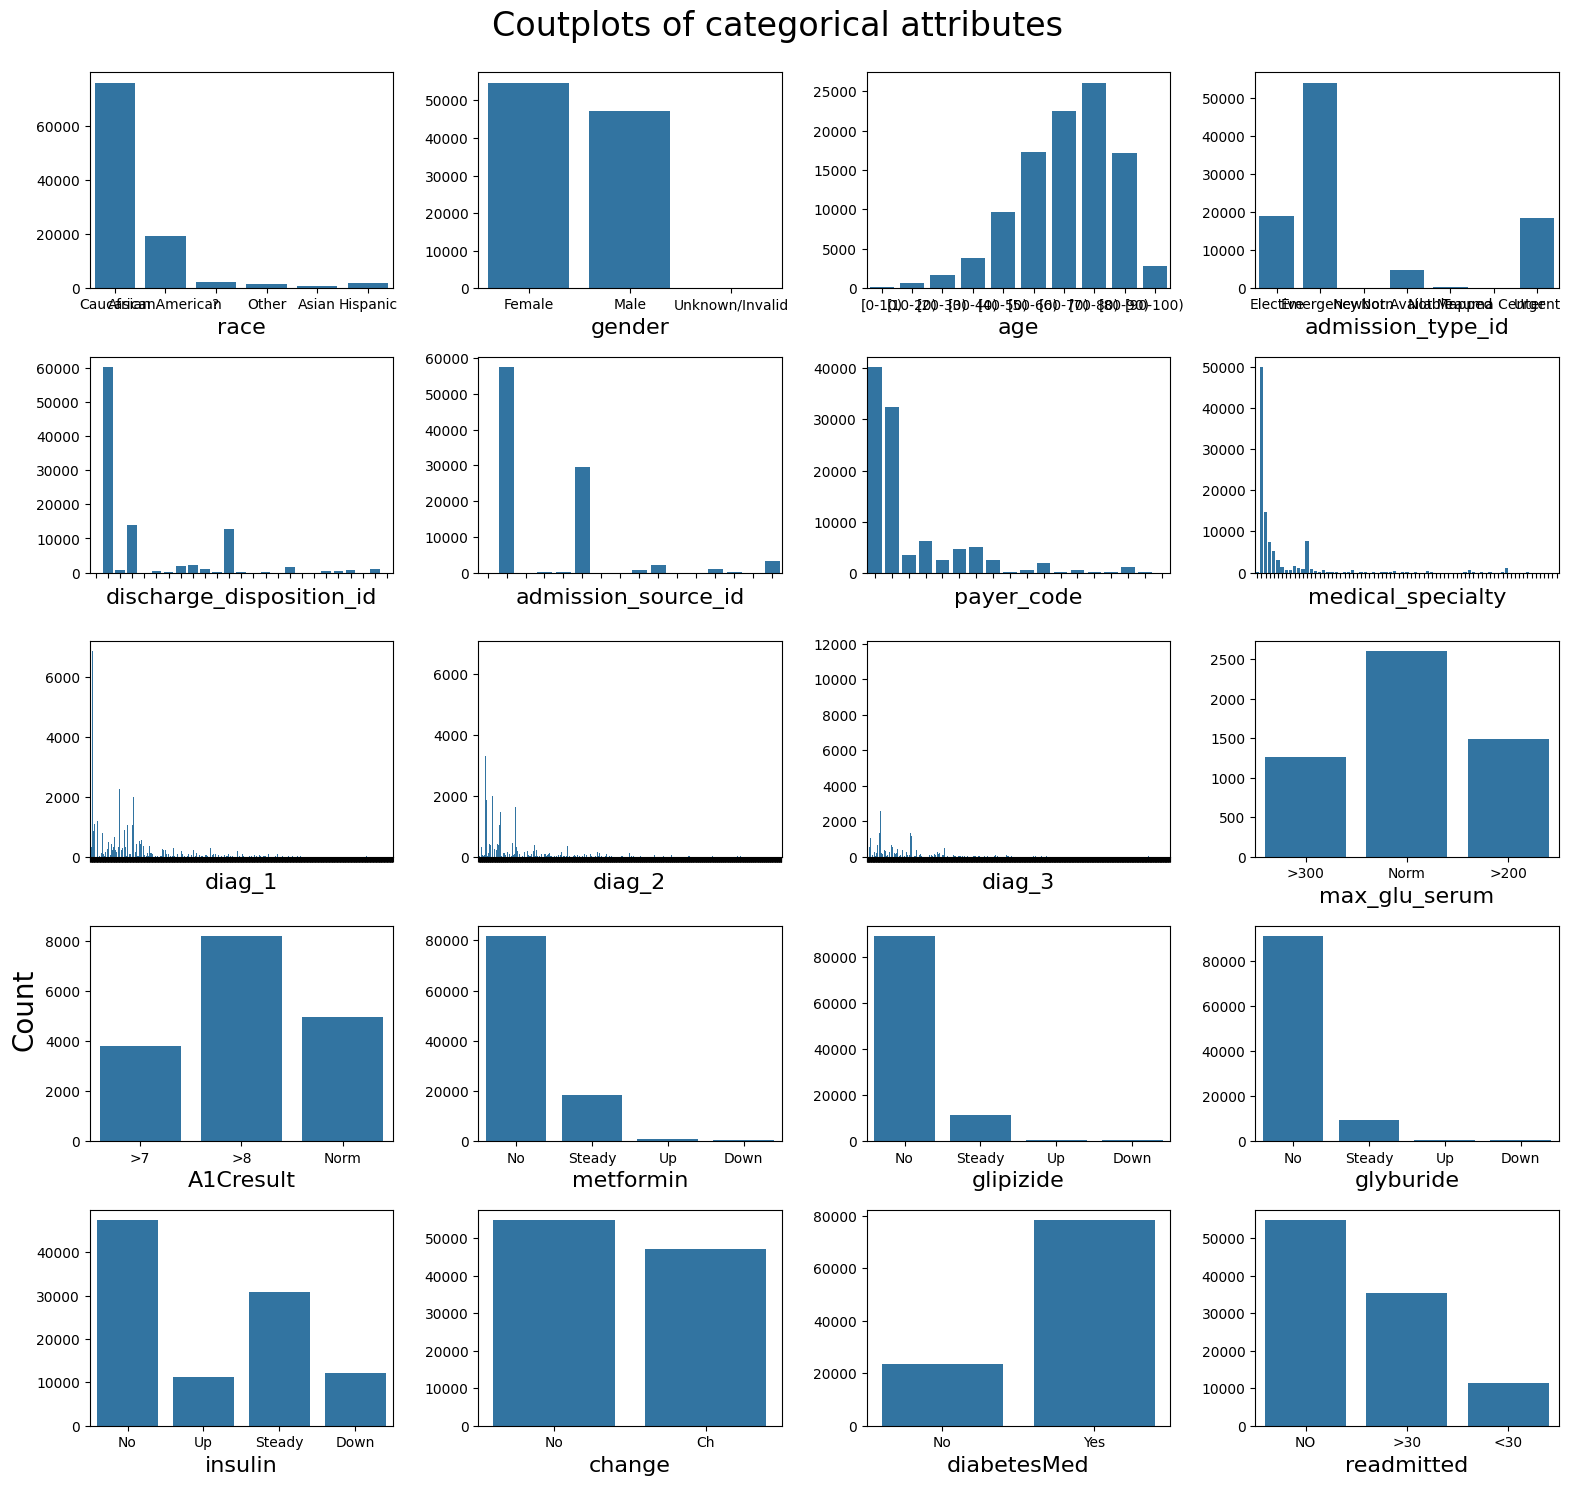

In [161]:
plot_numerical_cols(df)
plot_categorical_cols(df)

In [162]:
# only 3 rows with unknown gender, we drop these rows
df.drop(df[df['gender'] == 'Unknown/Invalid'].index, inplace=True)

In [163]:
df['payer_code'].value_counts()

payer_code
?     40255
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2531
UN     2448
CM     1937
OG     1033
PO      592
DM      549
CH      146
WC      135
OT       95
MP       79
SI       55
FR        1
Name: count, dtype: int64

In [164]:
# TODO: do we keep the payer code and continue working with it or we should just drop it? 
payer_code_mapping = {'MC': '',
					  'HM': '',
					  'SP': '',
					  'BC': '',
					  'MC': '',
					  'CP': '',
					  'UN': '',
					  'CM': '',
					  'OG': '',
					  'PO': '',
					  'DM': '',
					  'CH': '',
					  'WC': '',
					  'OT': '',
					  'MP': '',
					  'SI': '',
					  'FR': ''}

We can see that this column has a lot of values, now we try to reduce them:

In [165]:
df['diag_1'].value_counts()


diag_1
428    6862
414    6580
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 717, dtype: int64